# Modeling — Random Forest Classifier

---

1. Import packages
2. Load data
3. Train / Test split
4. Model training
5. Model evaluation
6. Feature importance
7. Conclusions

---

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      roc_auc_score,
                                      roc_curve,
                                      accuracy_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load final dataset prepared after feature engineering
df = pd.read_csv('data_for_predictions.csv')

print(f"Data loaded successfully!")
print(f"Shape : {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"\nChurn distribution:")
print(f"  Retained : {(df['churn']==0).sum():,} ({(df['churn']==0).mean()*100:.1f}%)")
print(f"  Churned  : {(df['churn']==1).sum():,} ({(df['churn']==1).mean()*100:.1f}%)")
display(df.head())

Data loaded successfully!
Shape : 14,606 rows | 64 columns

Churn distribution:
  Retained : 13,187 (90.3%)
  Churned  : 1,419 (9.7%)


,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


### Observation — Dataset Overview

- Dataset has **64 columns** — significantly enriched from original 26
- Estelle has already encoded categorical variables (channel, origin_up)
- Class imbalance present — **90.3% retained vs 9.7% churned**
- This imbalance must be handled carefully during model training
- We will use `class_weight='balanced'` in Random Forest to address this

## 3. Train / Test Split

In [3]:
# Separate features and target
# Drop id and unnamed index column
X = df.drop(columns=['churn', 'id', 'Unnamed: 0'], errors='ignore')
y = df['churn']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

# Train test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y  # maintain churn ratio in both sets
)

print(f"\nTrain set : {X_train.shape[0]:,} samples")
print(f"Test set  : {X_test.shape[0]:,} samples")
print(f"\nChurn ratio in train : {y_train.mean()*100:.1f}%")
print(f"Churn ratio in test  : {y_test.mean()*100:.1f}%")

Features shape : (14606, 61)
Target shape   : (14606,)

Train set : 11,684 samples
Test set  : 2,922 samples

Churn ratio in train : 9.7%
Churn ratio in test  : 9.7%


### Observation — Train / Test Split

- Dataset split into **80% train (11,684)** and **20% test (2,922)**
- `stratify=y` ensures churn ratio is maintained in both sets
- Both train and test have **9.7% churn rate** — no data leakage
- 61 features will be used for modeling

## 4. Model Training

In [4]:
# Random Forest Classifier
# class_weight='balanced' — handles class imbalance automatically
# n_estimators=1000 — more trees = more stable predictions
# max_depth=None — let trees grow fully
# random_state=42 — reproducibility

rf_model = RandomForestClassifier(
    n_estimators  = 1000,
    max_depth     = None,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1  # use all CPU cores
)

print("Training Random Forest model...")
print("(This may take a minute — 1000 trees!)")

rf_model.fit(X_train, y_train)

print("\nModel trained successfully!")
print(f"  Trees built      : {rf_model.n_estimators}")
print(f"  Features used    : {rf_model.n_features_in_}")
print(f"  Classes          : {rf_model.classes_}")

Training Random Forest model...
(This may take a minute — 1000 trees!)

Model trained successfully!
  Trees built      : 1000
  Features used    : 61
  Classes          : [0 1]


## 5. Model Evaluation

We evaluate using multiple metrics:
- **Accuracy** — overall correct predictions
- **ROC-AUC** — ability to distinguish churners from non-churners
- **Precision** — of predicted churners, how many actually churned
- **Recall** — of actual churners, how many did we catch
- **F1 Score** — balance between precision and recall

> For churn prediction, **Recall is most important** — missing a 
> churner (False Negative) is more costly than a false alarm.
> ROC-AUC gives the best overall picture for imbalanced datasets.

In [5]:
# Predictions
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("   MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"\nAccuracy  : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Retained', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:")
print(f"  True Negatives  (Retained correctly) : {cm[0][0]:,}")
print(f"  False Positives (Retained as Churned): {cm[0][1]:,}")
print(f"  False Negatives (Churned as Retained): {cm[1][0]:,}")
print(f"  True Positives  (Churned correctly)  : {cm[1][1]:,}")

   MODEL EVALUATION RESULTS

Accuracy  : 0.9100 (91.0%)
ROC-AUC   : 0.7059

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      1.00      0.95      2638
     Churned       0.89      0.08      0.15       284

    accuracy                           0.91      2922
   macro avg       0.90      0.54      0.55      2922
weighted avg       0.91      0.91      0.87      2922

Confusion Matrix:
  True Negatives  (Retained correctly) : 2,635
  False Positives (Retained as Churned): 3
  False Negatives (Churned as Retained): 260
  True Positives  (Churned correctly)  : 24


### Observation — Model Performance

**Accuracy: 91.0% — but this is misleading!**

- High accuracy is due to class imbalance — if we predicted 
  everyone as "Retained", we'd still get 90.3% accuracy
- **ROC-AUC: 0.7059** — model has moderate discriminating ability
- **Recall for Churned: only 8%** — model is missing 260 out of 
  284 actual churners — this is a critical weakness
- **Precision for Churned: 89%** — when it does predict churn, 
  it's usually correct

**Is the model satisfactory?**
- For business purposes — **No, not yet**
- Missing 260 churners means PowerCo cannot act on them
- Further improvements needed:
  - Try lower classification threshold (e.g. 0.3 instead of 0.5)
  - Try SMOTE oversampling
  - More feature engineering on price sensitivity
- However, ROC-AUC of 0.70 shows the model has **learned 
  meaningful patterns** — it's a good starting point

## 6. Visualizations

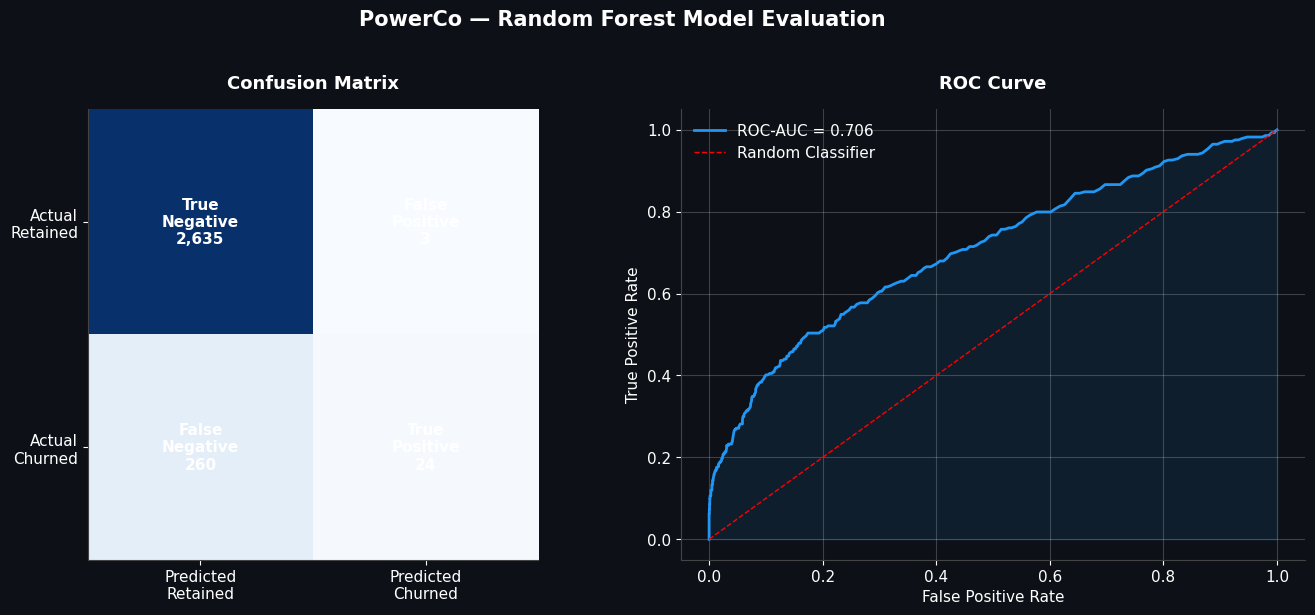

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

# Plot 1 — Confusion Matrix
cm_labels = [['True\nNegative\n2,635', 'False\nPositive\n3'],
             ['False\nNegative\n260',  'True\nPositive\n24']]

im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted\nRetained', 'Predicted\nChurned'],
                         color='white')
axes[0].set_yticklabels(['Actual\nRetained', 'Actual\nChurned'],
                         color='white')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_labels[i][j],
                     ha='center', va='center',
                     color='white', fontsize=11,
                     fontweight='bold')
axes[0].set_title('Confusion Matrix',
                   fontsize=13, fontweight='bold',
                   color='white', pad=15)

# Plot 2 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2196F3', linewidth=2,
             label=f'ROC-AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'r--', linewidth=1,
             label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_title('ROC Curve',
                   fontsize=13, fontweight='bold',
                   color='white', pad=15)
axes[1].set_xlabel('False Positive Rate', color='white')
axes[1].set_ylabel('True Positive Rate', color='white')
axes[1].legend(frameon=False, labelcolor='white')
axes[1].grid(alpha=0.2, color='white')

plt.suptitle('PowerCo — Random Forest Model Evaluation',
             fontsize=15, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

## 7. Feature Importance

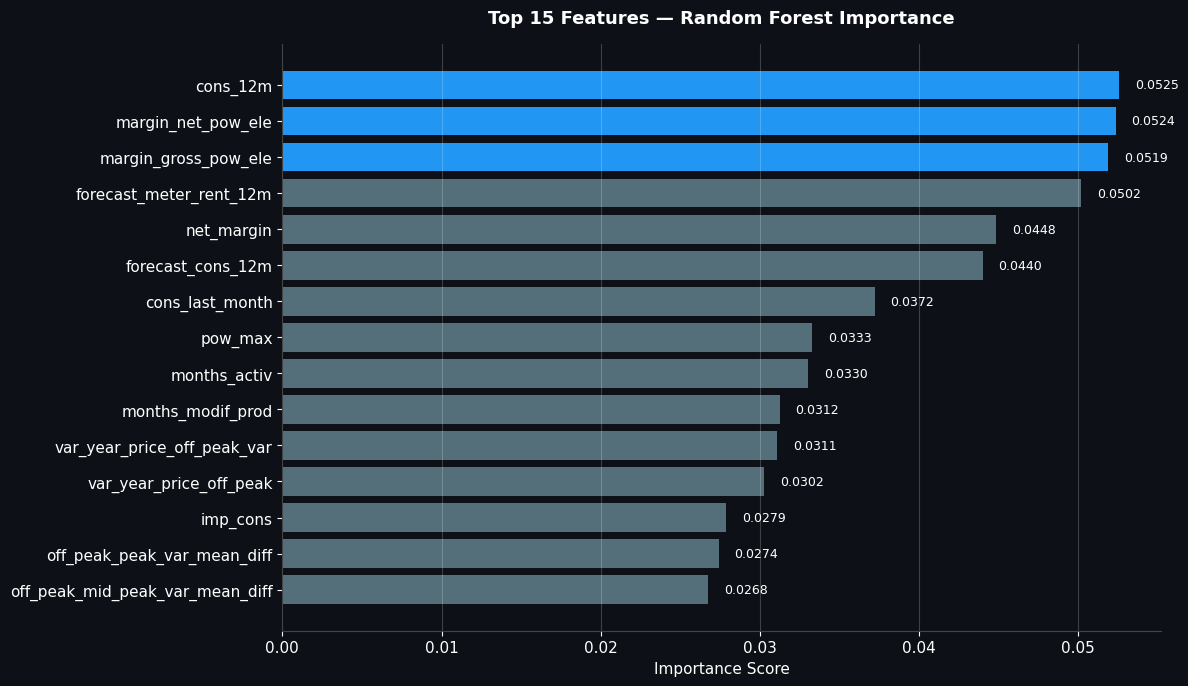


Top 5 Most Important Features:
  cons_12m                            : 0.0525
  margin_net_pow_ele                  : 0.0524
  margin_gross_pow_ele                : 0.0519
  forecast_meter_rent_12m             : 0.0502
  net_margin                          : 0.0448


In [7]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='white')

colors = ['#2196F3' if i < 3 else '#546E7A'
          for i in range(len(importance_df))]

bars = ax.barh(importance_df['feature'][::-1],
               importance_df['importance'][::-1],
               color=colors[::-1], edgecolor='none')

ax.set_title('Top 15 Features — Random Forest Importance',
             fontsize=13, fontweight='bold',
             color='white', pad=15)
ax.set_xlabel('Importance Score', color='white')

for bar, val in zip(bars, importance_df['importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            color='white', fontsize=9)

ax.grid(axis='x', alpha=0.2, color='white')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

print("\nTop 5 Most Important Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:<35} : {row['importance']:.4f}")

### Observation — Feature Importance

- **cons_12m (0.0525)** — 12-month electricity consumption is the 
  strongest predictor — high consumers may have more options available
- **margin_net_pow_ele (0.0524)** and **margin_gross_pow_ele (0.0519)** — 
  profit margin features are almost equally important — PowerCo's 
  most profitable customers are at highest risk
- **Price features** (var_year_price_off_peak) appear in top 15 — 
  confirming price sensitivity does play a role, but is NOT the 
  primary driver
- **months_activ (0.0330)** — customer tenure matters — newer 
  customers churn more as seen in EDA
- **Key Insight:** Churn is driven by a combination of consumption, 
  margin and price — not price alone — this challenges PowerCo's 
  original hypothesis

## 8. Conclusions

### Final Conclusions

**Model Performance:**
- Accuracy: 91.0% — misleading due to class imbalance
- ROC-AUC: 0.706 — model has learned meaningful patterns
- Recall for churned customers: only 8% — needs improvement
- The model is a **good starting point** but not production-ready

**Answer to PowerCo's Hypothesis:**
> *"Is price sensitivity the primary driver of churn?"*

- **Partially — but No**
- Price features appear in top 15 but are NOT the top drivers
- **Consumption and margin are stronger predictors**
- Customers who consume more and generate higher margins 
  are actually more likely to churn — they have more options

**Business Recommendations:**
1. Focus retention efforts on **high-consumption, high-margin** customers
2. Offer **personalized pricing** to price-sensitive customers
3. Target customers in their **first 2 years** — highest churn risk
4. Investigate why **profitable customers** are leaving — 
   competitor offers may be more attractive for large consumers
5. Lower classification threshold to **0.3** to catch more churners

**Next Steps for Model Improvement:**
- Apply SMOTE to handle class imbalance
- Tune hyperparameters using GridSearchCV
- Engineer more price sensitivity features
- Try XGBoost or LightGBM for comparison